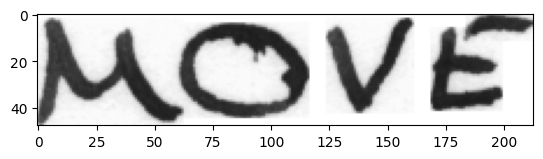

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("../Datasets/iam_words/words/a01/a01-000u/a01-000u-00-01.png")
plt.imshow(img, cmap="gray")
plt.show()

In [2]:
import pandas as pd
import os

dataset = []

with open("../Datasets/iam_words/words.txt", "r") as f:
    for line in f:
        if line.startswith("#"):
            continue

        parts = line.strip().split()

        if len(parts) < 9:
            continue

        word_id = parts[0]
        status = parts[1]

        if status != "ok":
            continue

        label = " ".join(parts[8:])

        folder1 = word_id.split("-")[0]
        folder2 = "-".join(word_id.split("-")[:2])

        image_path = f"../Datasets/iam_words/words/{folder1}/{folder2}/{word_id}.png"

        if os.path.exists(image_path):
            dataset.append([image_path, label])

df = pd.DataFrame(dataset, columns=["image_path", "label"])

print(df.head())
print("Total samples:", len(df))

                                          image_path label
0  ../Datasets/iam_words/words/a01/a01-000u/a01-0...     A
1  ../Datasets/iam_words/words/a01/a01-000u/a01-0...  MOVE
2  ../Datasets/iam_words/words/a01/a01-000u/a01-0...    to
3  ../Datasets/iam_words/words/a01/a01-000u/a01-0...  stop
4  ../Datasets/iam_words/words/a01/a01-000u/a01-0...   Mr.
Total samples: 38305


In [3]:
characters = set()

for text in df["label"]:
    characters.update(text)

vocab = sorted(list(characters))

print(vocab)
print("Vocabulary Size:", len(vocab))

[' ', '!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Vocabulary Size: 77


In [4]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print(len(train_df))
print(len(val_df))

34474
3831


In [5]:
import cv2
import numpy as np

heights = []
widths = []

for path in df["image_path"][:1000]:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    heights.append(img.shape[0])
    widths.append(img.shape[1])

print("Height:")
print("Min:", min(heights))
print("Max:", max(heights))

print("Width:")
print("Min:", min(widths))
print("Max:", max(widths))

Height:
Min: 4
Max: 200
Width:
Min: 4
Max: 640


In [6]:
char_to_idx = {char: idx + 1 for idx, char in enumerate(vocab)}
idx_to_char = {idx + 1: char for idx, char in enumerate(vocab)}

print(char_to_idx['A'])
print(idx_to_char[1])

26
 


In [7]:
def encode_text(text):
    return [char_to_idx[c] for c in text]

print(encode_text("MOVE"))

[38, 40, 47, 30]


In [108]:
import cv2
import numpy as np

IMG_H = 32
IMG_W = 256

def preprocess_image(path, augment=False):

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Could not load image: {path}"
        )

    if augment:
        img = augment_image(img)

    h, w = img.shape

    scale = IMG_H / h

    new_w = min(
        int(w * scale),
        IMG_W
    )

    img = cv2.resize(
        img,
        (new_w, IMG_H)
    )

    canvas = np.ones(
        (IMG_H, IMG_W),
        dtype=np.uint8
    ) * 255

    canvas[:, :new_w] = img

    canvas = canvas.astype(
        np.float32
    ) / 255.0

    # OCR usually learns better with:
    # background = 0
    # text = 1
    canvas = 1.0 - canvas

    return canvas

In [109]:
sample = preprocess_image(df.iloc[1]["image_path"])

print(sample.shape)

(32, 256)


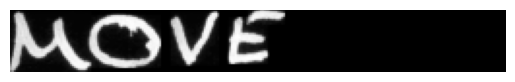

In [110]:
import matplotlib.pyplot as plt

plt.imshow(sample, cmap="gray")
plt.axis("off")
plt.show()

In [111]:
print(sample.shape)

(32, 256)


In [115]:
import torch
from torch.utils.data import Dataset

class IAMDataset(Dataset):

    def __init__(
        self,
        dataframe,
        augment=False
    ):
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        image = preprocess_image(
            image_path,
            augment=self.augment
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        encoded_label = torch.tensor(
            encode_text(label),
            dtype=torch.long
        )

        return image, encoded_label, label

In [116]:
small_train = train_df.sample(
    5000,
    random_state=42
)

small_val = val_df.sample(
    500,
    random_state=42
)

In [117]:
train_dataset = IAMDataset(small_train)
val_dataset = IAMDataset(small_val)

In [118]:
img, enc, txt = train_dataset[0]

print(img.shape)
print(enc)
print(txt)

torch.Size([1, 32, 256])
tensor([37, 52, 53, 11])
Lab.


In [119]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    images = []
    labels = []
    lengths = []

    for image, label, _ in batch:
        images.append(image)
        labels.append(label)
        lengths.append(len(label))

    images = torch.stack(images)

    labels = pad_sequence(
        labels,
        batch_first=True,
        padding_value=0
    )

    lengths = torch.tensor(lengths)

    return images, labels, lengths

In [120]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [121]:
images, labels, lengths = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(lengths.shape)

torch.Size([32, 1, 32, 256])
torch.Size([32, 12])
torch.Size([32])


In [122]:
images, labels, lengths = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(lengths)

torch.Size([32, 1, 32, 256])
torch.Size([32, 13])
tensor([ 3,  7,  7,  3,  3,  4,  4,  9,  3,  5,  9, 10,  5,  5,  8,  6,  4,  7,
         3,  8,  3,  6,  3,  7,  6,  2,  5,  1,  4,  5,  7, 13])


In [123]:
import torch
import torch.nn as nn

class OCRModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            input_size=128 * 8,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(
            512,
            num_classes + 1
        )

    def forward(self, x):
        x = self.cnn(x)

        b, c, h, w = x.size()

        x = x.permute(0, 3, 1, 2)

        x = x.contiguous().view(
            b,
            w,
            c * h
        )

        x, _ = self.lstm(x)

        x = self.fc(x)

        return x

In [124]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = OCRModel(
    num_classes=len(vocab)
).to(device)

print(model)

OCRModel(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (lstm): LSTM(1024, 256, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=78, bias=True)
)


In [125]:
images, labels, lengths = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 64, 78])


In [126]:
ctc_loss = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

In [127]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [128]:
outputs = model(images.to(device))
print(outputs.shape)

torch.Size([32, 64, 78])


In [129]:
tiny_train = train_df.sample(
    500,
    random_state=42
)

tiny_dataset = IAMDataset(tiny_train)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

In [130]:
ctc_loss = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [131]:
def train_epoch():
    model.train()

    total_loss = 0

    for images, labels, label_lengths in tiny_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        outputs = outputs.log_softmax(2)

        outputs = outputs.permute(1, 0, 2)

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=outputs.size(0),
            dtype=torch.long
        ).to(device)

        target_lengths = label_lengths.to(device)

        loss = ctc_loss(
            outputs,
            labels,
            input_lengths,
            target_lengths
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(tiny_loader)

In [132]:
for epoch in range(10):
    loss = train_epoch()

    print(
        f"Epoch {epoch+1}: "
        f"Loss = {loss:.4f}"
    )

Epoch 1: Loss = 27.3128
Epoch 2: Loss = 4.2006
Epoch 3: Loss = 4.0374
Epoch 4: Loss = 3.9966
Epoch 5: Loss = 3.9858
Epoch 6: Loss = 3.9936
Epoch 7: Loss = 3.9992
Epoch 8: Loss = 3.9814
Epoch 9: Loss = 3.9841
Epoch 10: Loss = 3.9788


In [133]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.1+cu126
12.6
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [134]:
import torch

print(torch.__version__)
print(torch.version.cuda)

2.12.1+cu126
12.6


In [135]:
import sys
print(sys.executable)

C:\Users\User\AppData\Local\Programs\Python\Python310\python.exe


In [136]:
def decode_prediction(output):
    pred = output.argmax(1)

    text = ""
    prev = 0

    for p in pred:
        p = p.item()

        if p != prev and p != 0:
            text += idx_to_char[p]

        prev = p

    return text

In [137]:
model.eval()

images, labels, lengths = next(iter(tiny_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

prediction = decode_prediction(outputs[0])

print("Prediction:", prediction)

Prediction: 


In [138]:
_, _, actual = tiny_dataset[0]

print("Actual:", actual)

Actual: Lab.


In [139]:
images, labels, lengths = next(iter(tiny_loader))

with torch.no_grad():
    outputs = model(images.to(device))

print(decode_prediction(outputs[0]))

In [140]:
label_indices = labels[0][:lengths[0]]

actual = "".join(
    idx_to_char[i.item()]
    for i in label_indices
)

print(actual)

with


In [38]:
for epoch in range(50):
    loss = train_epoch()

    if epoch % 5 == 0:
        print(epoch, loss)

0 3.9084105491638184
5 3.5534972697496414
10 3.2797525972127914
15 2.9603618681430817
20 2.644696369767189
25 2.436058908700943
30 2.1996528059244156
35 1.9360639229416847
40 1.6557748764753342
45 1.4268114194273949


In [39]:
tiny_train = train_df.sample(
    100,
    random_state=42
)

In [40]:
with torch.no_grad():
    outputs = model(images.to(device))

pred = outputs[0].argmax(1)

print(pred[:30])

tensor([71, 56, 52,  0,  0,  0,  0,  0, 59,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], device='cuda:0')


In [41]:
hidden_size=256
hidden_size=512

In [42]:
easy_df = train_df[
    train_df["label"].str.len() <= 4
]

tiny_train = easy_df.sample(
    200,
    random_state=42
)

In [43]:
for epoch in range(100):
    loss = train_epoch()

    if epoch % 10 == 0:
        print(epoch, loss)

0 1.1167731061577797
10 0.6948052626103163
20 0.38332817424088717
30 0.18631425220519304
40 0.09345502918586135
50 0.04604912071954459
60 0.02736203616950661
70 0.016488991561345756
80 0.06029391719494015
90 0.07248554890975356


In [44]:
model.eval()

images, labels, lengths = next(iter(tiny_loader))

with torch.no_grad():
    outputs = model(images.to(device))

print(decode_prediction(outputs[0]))

cinema


In [45]:
print(idx_to_char[66])

o


In [46]:
tiny_train = train_df.sample(
    100,
    random_state=42
)

In [47]:
model = OCRModel(
    num_classes=len(vocab)
).to(device)

In [48]:
for epoch in range(100):
    loss = train_epoch()

    if epoch % 10 == 0:
        print(epoch, loss)

0 49.45135140419006
10 49.26593089103699
20 49.146968603134155
30 49.16678786277771
40 49.362213373184204
50 49.228073596954346
60 49.40176343917847
70 49.30602669715881
80 49.545992851257324
90 49.08399486541748


In [49]:
model.eval()

images, labels, lengths = next(iter(tiny_loader))

with torch.no_grad():
    outputs = model(images.to(device))

prediction = decode_prediction(outputs[0])

label_indices = labels[0][:lengths[0]]

actual = "".join(
    idx_to_char[i.item()]
    for i in label_indices
)

print("Prediction:", prediction)
print("Actual:", actual)

Prediction: k
Actual: miracle


In [50]:
IMG_W = 256
IMG_H = 32

In [51]:
def decode_prediction(output):
    pred = output.argmax(1)

    text = ""
    prev = 0

    for p in pred:
        p = p.item()

        if p != prev and p != 0:
            text += idx_to_char[p]

        prev = p

    return text

In [52]:
model.eval()

correct = 0
total = 20

with torch.no_grad():

    for i in range(total):

        image, _, actual = tiny_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

        print(
            f"Pred: {pred:15s} | Actual: {actual}"
        )

print(
    f"Accuracy: {correct}/{total}"
)

Pred: k               | Actual: Lab.
Pred: k               | Actual: the
Pred: k               | Actual: but
Pred: k               | Actual: theme
Pred: k               | Actual: Jun.
Pred: k               | Actual: 're
Pred: k               | Actual: suitability
Pred: k               | Actual: it
Pred: k               | Actual: diligently
Pred: k               | Actual: adamant
Pred: k               | Actual: largely
Pred: k               | Actual: cinema
Pred: k               | Actual: working
Pred: k               | Actual: suggest
Pred: k               | Actual: an
Pred: k               | Actual: forecast
Pred: k               | Actual: From
Pred: k               | Actual: book
Pred: k               | Actual: a
Pred: k               | Actual: the
Accuracy: 0/20


In [141]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003
)

In [142]:
easy_df = train_df[
    train_df["label"].str.len() <= 3
]

In [143]:
tiny_train = easy_df.sample(100, random_state=42)

In [144]:
with torch.no_grad():
    outputs = model(images.to(device))

print(outputs[0].argmax(1))

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [145]:
def collate_fn(batch):
    images = []
    labels = []
    label_lengths = []

    for image, label, _ in batch:
        images.append(image)
        labels.append(label)
        label_lengths.append(len(label))

    images = torch.stack(images)

    labels = torch.cat(labels)

    label_lengths = torch.tensor(
        label_lengths,
        dtype=torch.long
    )

    return images, labels, label_lengths

In [146]:
input_lengths = torch.full(
    (images.size(0),),
    outputs.size(0),
    dtype=torch.long,
    device=device
)

In [147]:
outputs = outputs.permute(1, 0, 2)

In [148]:
def collate_fn(batch):
    images = []
    labels = []
    label_lengths = []

    for image, label, _ in batch:
        images.append(image)
        labels.append(label)
        label_lengths.append(len(label))

    images = torch.stack(images)

    labels = torch.cat(labels)

    label_lengths = torch.tensor(
        label_lengths,
        dtype=torch.long
    )

    return images, labels, label_lengths

In [149]:
def train_epoch():
    model.train()

    total_loss = 0

    for images, labels, label_lengths in tiny_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        outputs = outputs.log_softmax(2)

        outputs = outputs.permute(1, 0, 2)

        input_lengths = torch.full(
            (images.size(0),),
            outputs.size(0),
            dtype=torch.long,
            device=device
        )

        target_lengths = label_lengths.to(device)

        loss = ctc_loss(
            outputs,
            labels,
            input_lengths,
            target_lengths
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(tiny_loader)

In [150]:
tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

In [151]:
model = OCRModel(
    num_classes=len(vocab)
).to(device)

In [152]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003
)

In [153]:
images, labels, lengths = next(iter(tiny_loader))

print(images.shape)
print(labels.shape)
print(lengths[:10])

torch.Size([32, 1, 32, 256])
torch.Size([117])
tensor([7, 6, 3, 4, 3, 8, 4, 2, 3, 3])


In [154]:
ctc_loss = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

In [155]:
for epoch in range(100):
    loss = train_epoch()

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: {loss:.4f}")

Epoch 0: 56.5002
Epoch 5: 3.9389
Epoch 10: 3.7576
Epoch 15: 3.3290
Epoch 20: 2.8839
Epoch 25: 2.6365
Epoch 30: 2.4408
Epoch 35: 2.2212
Epoch 40: 2.0324
Epoch 45: 1.8112
Epoch 50: 1.6123
Epoch 55: 1.4445
Epoch 60: 1.2436
Epoch 65: 1.0881
Epoch 70: 0.9064
Epoch 75: 0.7502
Epoch 80: 0.6396
Epoch 85: 0.5283
Epoch 90: 0.4231
Epoch 95: 0.3459


In [156]:
model.eval()

images, labels, lengths = next(iter(tiny_loader))

with torch.no_grad():
    outputs = model(images.to(device))

pred = decode_prediction(outputs[0])

print("Prediction:", pred)

Prediction: .


In [157]:
model.eval()

correct = 0
total = 20

with torch.no_grad():

    for i in range(total):

        image, _, actual = tiny_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

        print(
            f"Pred: {pred:15s} | Actual: {actual}"
        )

print(
    f"Accuracy: {correct}/{total}"
)

Pred: Lab             | Actual: Lab.
Pred: the             | Actual: the
Pred: but             | Actual: but
Pred: the             | Actual: theme
Pred: Jun.            | Actual: Jun.
Pred: 're             | Actual: 're
Pred: suii            | Actual: suitability
Pred: it              | Actual: it
Pred: siligently      | Actual: diligently
Pred: aa              | Actual: adamant
Pred: largely         | Actual: largely
Pred: cin             | Actual: cinema
Pred: workg           | Actual: working
Pred: suget           | Actual: suggest
Pred: an              | Actual: an
Pred: foret           | Actual: forecast
Pred: From            | Actual: From
Pred: bok             | Actual: book
Pred: a               | Actual: a
Pred: the             | Actual: the
Accuracy: 10/20


In [70]:
small_train = train_df.sample(
    5000,
    random_state=42
)

In [71]:
nn.Conv2d(1, 64, 3, padding=1)
nn.Conv2d(64, 128, 3, padding=1)
nn.Conv2d(128, 256, 3, padding=1)

Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [72]:
loss_history = []

for epoch in range(50):
    loss = train_epoch()

    loss_history.append(loss)

    print(f"Epoch {epoch}: {loss:.4f}")

Epoch 0: 0.3410
Epoch 1: 0.3182
Epoch 2: 0.3057
Epoch 3: 0.3011
Epoch 4: 0.2865
Epoch 5: 0.2770
Epoch 6: 0.2711
Epoch 7: 0.2605
Epoch 8: 0.2472
Epoch 9: 0.2383
Epoch 10: 0.2253
Epoch 11: 0.2180
Epoch 12: 0.2081
Epoch 13: 0.2025
Epoch 14: 0.1903
Epoch 15: 0.1838
Epoch 16: 0.1746
Epoch 17: 0.1694
Epoch 18: 0.1566
Epoch 19: 0.1538
Epoch 20: 0.1447
Epoch 21: 0.1414
Epoch 22: 0.1401
Epoch 23: 0.1297
Epoch 24: 0.1211
Epoch 25: 0.1135
Epoch 26: 0.1077
Epoch 27: 0.1017
Epoch 28: 0.0946
Epoch 29: 0.0893
Epoch 30: 0.0832
Epoch 31: 0.0797
Epoch 32: 0.0761
Epoch 33: 0.0753
Epoch 34: 0.0721
Epoch 35: 0.0677
Epoch 36: 0.0648
Epoch 37: 0.0615
Epoch 38: 0.0589
Epoch 39: 0.0577
Epoch 40: 0.0564
Epoch 41: 0.0535
Epoch 42: 0.0513
Epoch 43: 0.0492
Epoch 44: 0.0473
Epoch 45: 0.0449
Epoch 46: 0.0440
Epoch 47: 0.0437
Epoch 48: 0.0419
Epoch 49: 0.0416


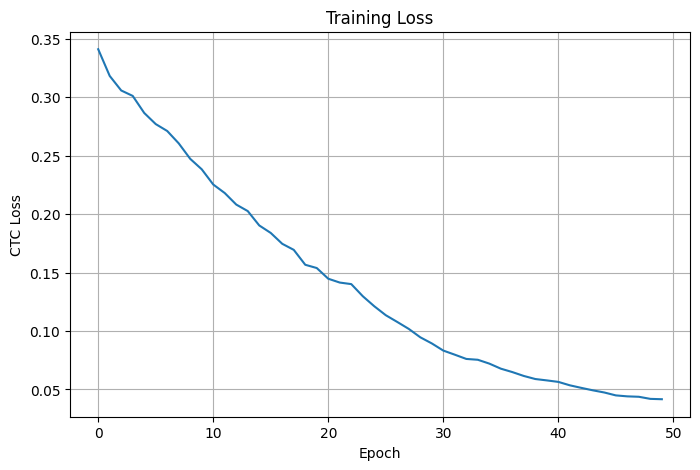

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [74]:
from jiwer import cer

actual = "Lab."
prediction = "La"

print(cer(actual, prediction))

0.5


In [75]:
cer_scores = []

for i in range(100):
    image, _, actual = val_dataset[i]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))

    pred = decode_prediction(output[0])

    cer_scores.append(cer(actual, pred))

avg_cer = sum(cer_scores)/len(cer_scores)

print(avg_cer)

0.6713437118437118


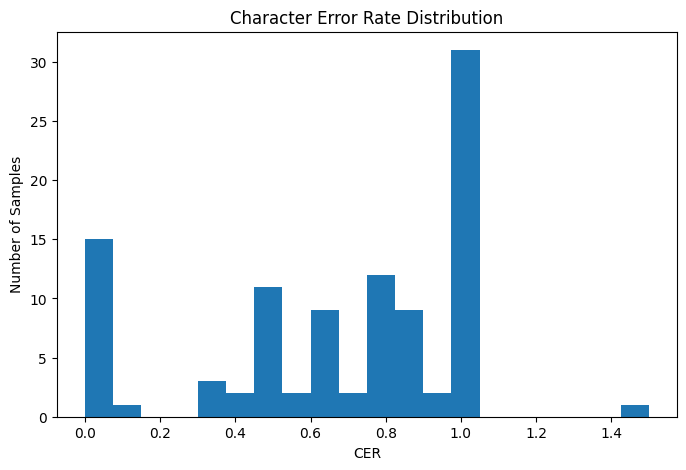

In [76]:
plt.figure(figsize=(8,5))
plt.hist(cer_scores, bins=20)
plt.xlabel("CER")
plt.ylabel("Number of Samples")
plt.title("Character Error Rate Distribution")
plt.show()

In [77]:
correct = 0
total = 500

for i in range(total):
    image, _, actual = val_dataset[i]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))

    pred = decode_prediction(output[0])

    if pred == actual:
        correct += 1

accuracy = correct / total

print(accuracy)

0.194


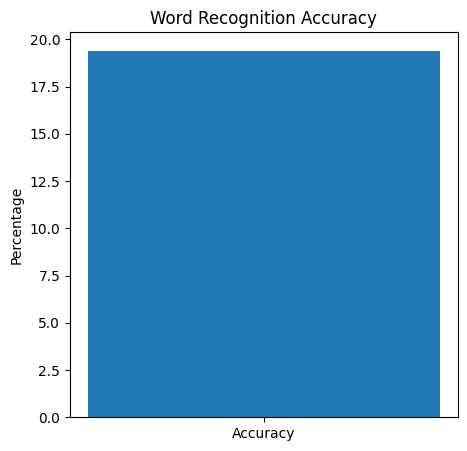

In [78]:
plt.figure(figsize=(5,5))
plt.bar(
    ["Accuracy"],
    [accuracy * 100]
)

plt.ylabel("Percentage")
plt.title("Word Recognition Accuracy")
plt.show()

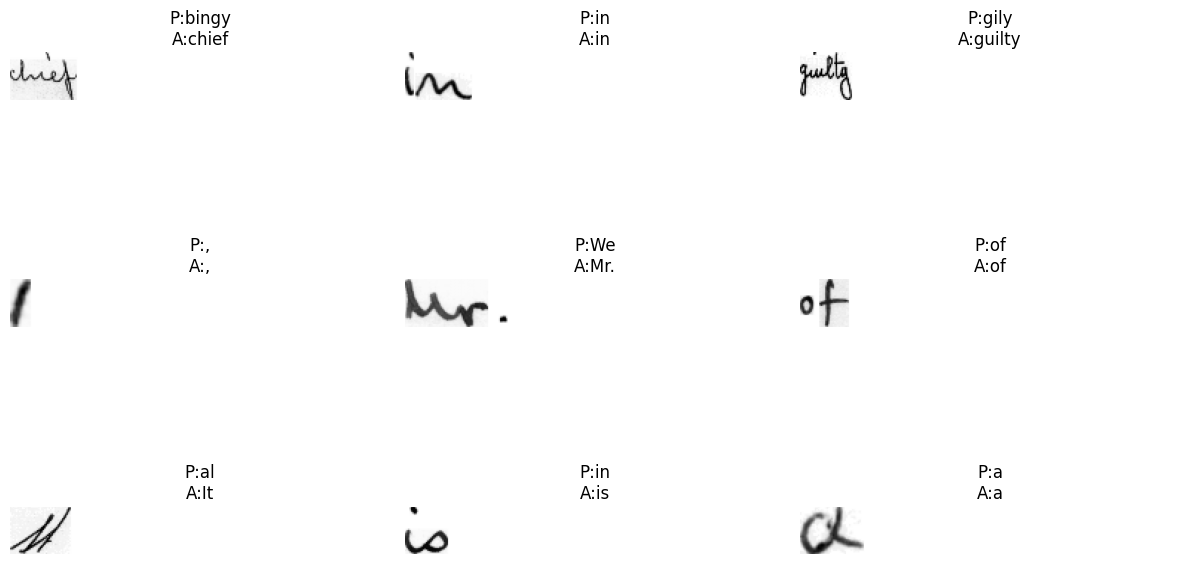

In [79]:
fig, axes = plt.subplots(3, 3, figsize=(12,8))

for ax in axes.flatten():

    idx = np.random.randint(len(val_dataset))

    image, _, actual = val_dataset[idx]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

    pred = decode_prediction(output[0])

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"P:{pred}\nA:{actual}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [80]:
from jiwer import cer

cer_scores = []

for i in range(200):

    image, _, actual = val_dataset[i]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

    pred = decode_prediction(output[0])

    cer_scores.append(
        cer(actual, pred)
    )

avg_cer = sum(cer_scores) / len(cer_scores)

print("Average CER:", avg_cer)

Average CER: 0.64885699023199


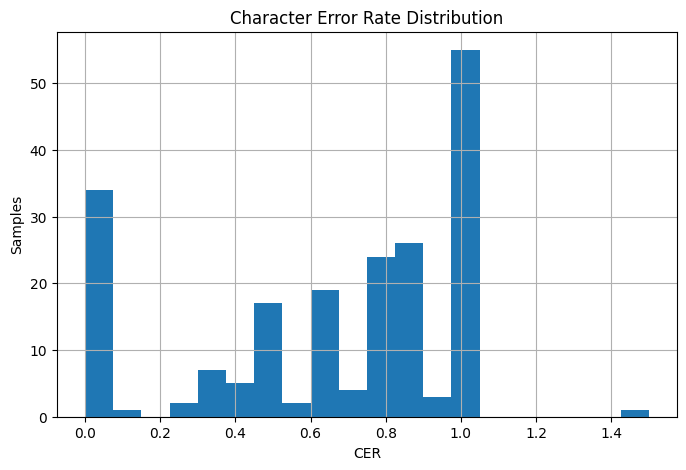

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(cer_scores, bins=20)

plt.title(
    "Character Error Rate Distribution"
)

plt.xlabel("CER")
plt.ylabel("Samples")

plt.grid(True)

plt.show()

In [82]:
small_train = train_df.sample(
    5000,
    random_state=42
)

In [83]:
for epoch in range(100):
    loss = train_epoch()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {loss:.4f}")

Epoch 0: 0.0389
Epoch 10: 0.0276
Epoch 20: 0.0210
Epoch 30: 0.0159
Epoch 40: 0.0127
Epoch 50: 0.0107
Epoch 60: 0.0087
Epoch 70: 0.0072
Epoch 80: 0.0064
Epoch 90: 0.5338


In [84]:
model.eval()

correct = 0
total = 20

with torch.no_grad():

    for i in range(total):

        image, _, actual = tiny_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

        print(
            f"Pred: {pred:15s} | Actual: {actual}"
        )

print(
    f"Accuracy: {correct}/{total}"
)

Pred: Lab.            | Actual: Lab.
Pred: the             | Actual: the
Pred: but             | Actual: but
Pred: theme           | Actual: theme
Pred: Jun.            | Actual: Jun.
Pred: 're             | Actual: 're
Pred: suitabity       | Actual: suitability
Pred: it              | Actual: it
Pred: diligently      | Actual: diligently
Pred: adamant         | Actual: adamant
Pred: largely         | Actual: largely
Pred: cinema          | Actual: cinema
Pred: working         | Actual: working
Pred: suggest         | Actual: suggest
Pred: an              | Actual: an
Pred: forecast        | Actual: forecast
Pred: From            | Actual: From
Pred: book            | Actual: book
Pred: a               | Actual: a
Pred: the             | Actual: the
Accuracy: 19/20


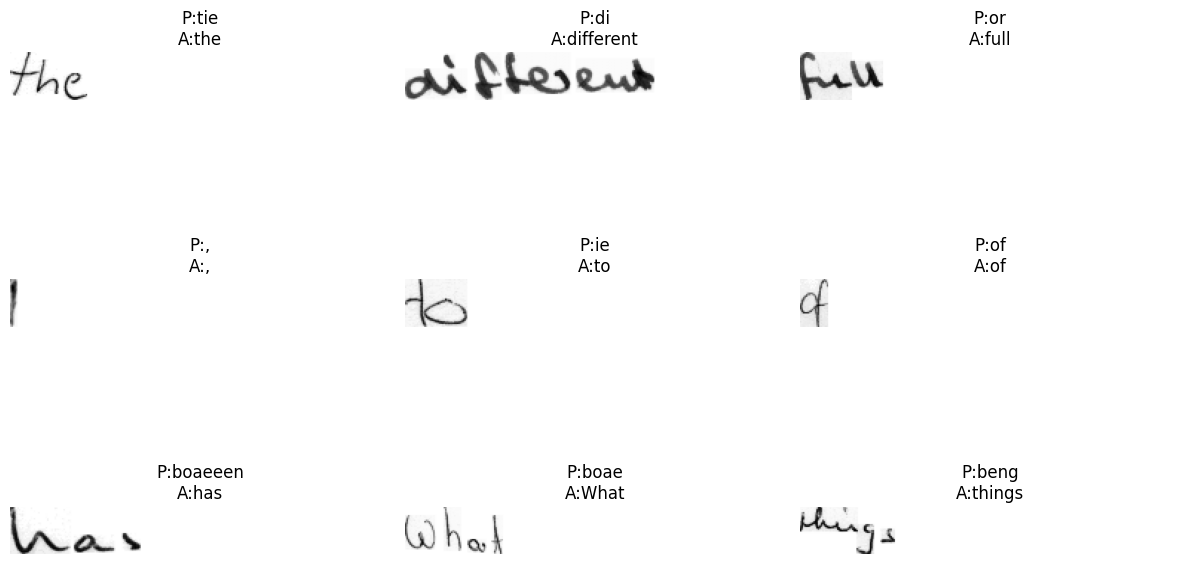

In [85]:
fig, axes = plt.subplots(3, 3, figsize=(12,8))

for ax in axes.flatten():

    idx = np.random.randint(len(val_dataset))

    image, _, actual = val_dataset[idx]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

    pred = decode_prediction(output[0])

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"P:{pred}\nA:{actual}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [86]:
small_train = train_df.sample(
    15000,
    random_state=42
)

In [87]:
for epoch in range(100):
    loss = train_epoch()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {loss:.4f}")

Epoch 0: 0.0227
Epoch 10: 0.0094
Epoch 20: 0.0069
Epoch 30: 0.0054
Epoch 40: 0.0045
Epoch 50: 0.0038
Epoch 60: 0.0032
Epoch 70: 0.0028
Epoch 80: 0.0025
Epoch 90: 0.0022


In [88]:
model.eval()

correct = 0
total = 20

with torch.no_grad():

    for i in range(total):

        image, _, actual = tiny_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

        print(
            f"Pred: {pred:15s} | Actual: {actual}"
        )

print(
    f"Accuracy: {correct}/{total}"
)

Pred: Lab.            | Actual: Lab.
Pred: the             | Actual: the
Pred: but             | Actual: but
Pred: theme           | Actual: theme
Pred: Jun.            | Actual: Jun.
Pred: 're             | Actual: 're
Pred: suitability     | Actual: suitability
Pred: it              | Actual: it
Pred: diligently      | Actual: diligently
Pred: adamant         | Actual: adamant
Pred: largely         | Actual: largely
Pred: cinema          | Actual: cinema
Pred: working         | Actual: working
Pred: suggest         | Actual: suggest
Pred: an              | Actual: an
Pred: forecast        | Actual: forecast
Pred: From            | Actual: From
Pred: book            | Actual: book
Pred: a               | Actual: a
Pred: the             | Actual: the
Accuracy: 20/20


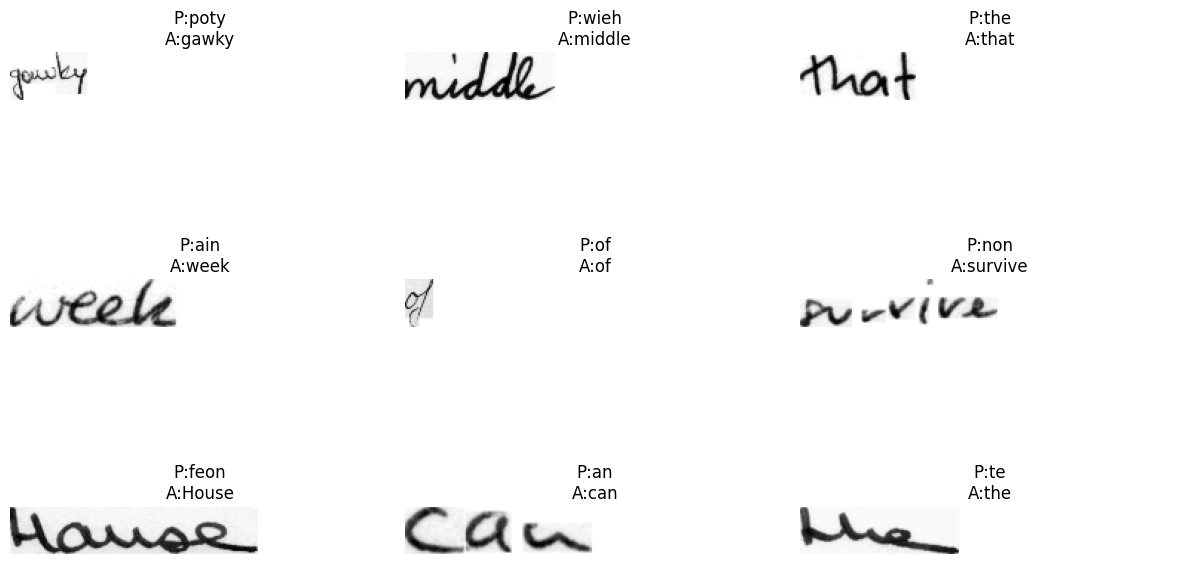

In [89]:
fig, axes = plt.subplots(3, 3, figsize=(12,8))

for ax in axes.flatten():

    idx = np.random.randint(len(val_dataset))

    image, _, actual = val_dataset[idx]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

    pred = decode_prediction(output[0])

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"P:{pred}\nA:{actual}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [90]:
small_train = train_df

In [97]:
for epoch in range(50):
    loss = train_epoch()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: {loss:.4f}")

Epoch 0: 0.0005
Epoch 10: 0.0004
Epoch 20: 0.0004
Epoch 30: 0.0004
Epoch 40: 0.0003


In [98]:
model.eval()

correct = 0
total = 20

with torch.no_grad():

    for i in range(total):

        image, _, actual = tiny_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

        print(
            f"Pred: {pred:15s} | Actual: {actual}"
        )

print(
    f"Accuracy: {correct}/{total}"
)

Pred: Lab.            | Actual: Lab.
Pred: the             | Actual: the
Pred: but             | Actual: but
Pred: theme           | Actual: theme
Pred: Jun.            | Actual: Jun.
Pred: 're             | Actual: 're
Pred: suitability     | Actual: suitability
Pred: it              | Actual: it
Pred: diligently      | Actual: diligently
Pred: adamant         | Actual: adamant
Pred: largely         | Actual: largely
Pred: cinema          | Actual: cinema
Pred: working         | Actual: working
Pred: suggest         | Actual: suggest
Pred: an              | Actual: an
Pred: forecast        | Actual: forecast
Pred: From            | Actual: From
Pred: book            | Actual: book
Pred: a               | Actual: a
Pred: the             | Actual: the
Accuracy: 20/20


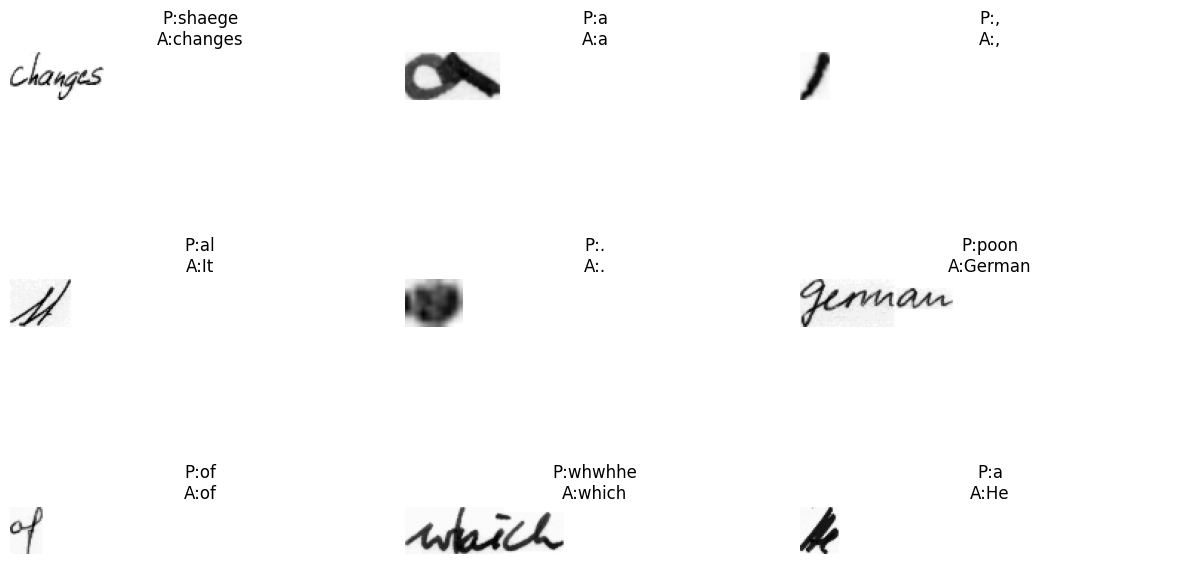

In [99]:
fig, axes = plt.subplots(3, 3, figsize=(12,8))

for ax in axes.flatten():

    idx = np.random.randint(len(val_dataset))

    image, _, actual = val_dataset[idx]

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

    pred = decode_prediction(output[0])

    ax.imshow(
        image.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"P:{pred}\nA:{actual}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [100]:
correct = 0
total = len(val_dataset)

model.eval()

with torch.no_grad():
    for i in range(total):

        image, _, actual = val_dataset[i]

        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

print(
    f"Accuracy: {correct/total:.4f}"
)

Accuracy: 0.1980


In [101]:
from jiwer import cer

cers = []

model.eval()

with torch.no_grad():

    for i in range(len(val_dataset)):

        image, _, actual = val_dataset[i]

        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = decode_prediction(output[0])

        cers.append(
            cer(actual, pred)
        )

print(
    "Average CER:",
    sum(cers) / len(cers)
)

Average CER: 0.6520170662670669


In [96]:
correct = 0
total = 500

model.eval()

with torch.no_grad():

    for i in range(total):

        image, _, actual = train_dataset[i]

        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

print("Train Accuracy:", correct / total)

Train Accuracy: 1.0


In [158]:
nn.Sequential(
    nn.Conv2d(1,64,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Dropout(0.3),

    nn.Conv2d(64,128,3,padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Dropout(0.3),

    nn.Conv2d(128,256,3,padding=1),
    nn.ReLU(),

    nn.Dropout(0.3)
)

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Dropout(p=0.3, inplace=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.3, inplace=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): Dropout(p=0.3, inplace=False)
)

In [159]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003
)

In [160]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-5
)

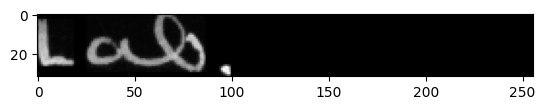

In [161]:
sample = train_dataset[0][0].squeeze().numpy()

plt.imshow(sample, cmap="gray")
plt.show()

In [107]:
def augment_image(img):

    h, w = img.shape

    angle = np.random.uniform(-5, 5)

    M = cv2.getRotationMatrix2D(
        (w//2, h//2),
        angle,
        1.0
    )

    img = cv2.warpAffine(
        img,
        M,
        (w, h),
        borderValue=255
    )

    tx = np.random.randint(-5, 6)
    ty = np.random.randint(-2, 3)

    M = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    img = cv2.warpAffine(
        img,
        M,
        (w, h),
        borderValue=255
    )

    return img

In [162]:
train_dataset = IAMDataset(
    small_train,
    augment=True
)

val_dataset = IAMDataset(
    val_df,
    augment=False
)

In [163]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

In [164]:
img, label, text = train_dataset[0]

print(img.shape)
print(label)
print(text)

torch.Size([1, 32, 256])
tensor([37, 52, 53, 11])
Lab.


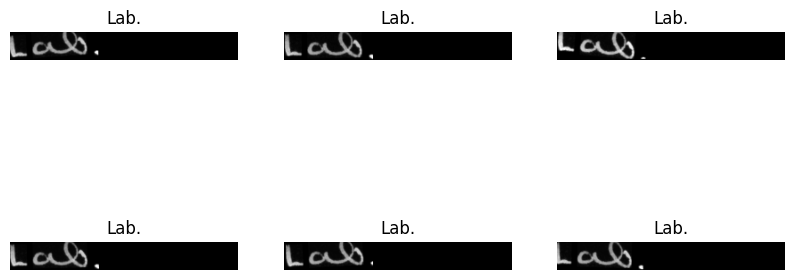

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):

    img, _, txt = train_dataset[0]

    plt.subplot(2,3,i+1)
    plt.imshow(
        img.squeeze(),
        cmap="gray"
    )
    plt.title(txt)
    plt.axis("off")

plt.show()

In [166]:
images, _, _ = next(iter(train_loader))

with torch.no_grad():
    x = model.cnn(images.to(device))

print(x.shape)

torch.Size([32, 128, 8, 64])


In [167]:
input_size = 256 * 8

In [168]:
hidden_size=512

In [169]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-5
)

In [170]:
model = OCRModel(
    num_classes=len(vocab)
).to(device)

In [171]:
loss_history = []

for epoch in range(50):

    loss = train_epoch()

    loss_history.append(loss)

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch}: {loss:.4f}"
        )

Epoch 0: 102.2676
Epoch 5: 102.7365
Epoch 10: 101.8752
Epoch 15: 101.9049
Epoch 20: 101.6564
Epoch 25: 102.5509
Epoch 30: 102.2261
Epoch 35: 101.9167
Epoch 40: 101.4038
Epoch 45: 101.7409


In [175]:
model.eval()

correct = 0
total = 500

with torch.no_grad():

    for i in range(total):

        image, _, actual = train_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

print("Train Accuracy:", correct / total)

Train Accuracy: 0.0


In [176]:
model.eval()

correct = 0
total = min(500, len(val_dataset))

with torch.no_grad():

    for i in range(total):

        image, _, actual = val_dataset[i]

        image = image.unsqueeze(0).to(device)

        output = model(image)

        pred = decode_prediction(output[0])

        if pred == actual:
            correct += 1

print("Validation Accuracy:", correct / total)

Validation Accuracy: 0.0


In [179]:
print(len(tiny_dataset))
print(len(train_dataset))
print(len(val_dataset))

500
5000
3831


In [182]:
model.eval()

image, _, actual = train_dataset[0]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))

pred = decode_prediction(output[0])

print("Prediction:", repr(pred))
print("Actual:", repr(actual))

Prediction: 'gNWNW'
Actual: 'Lab.'
